## 

## Finite Volume Method to Solve 1D Viscous Burger Equation:

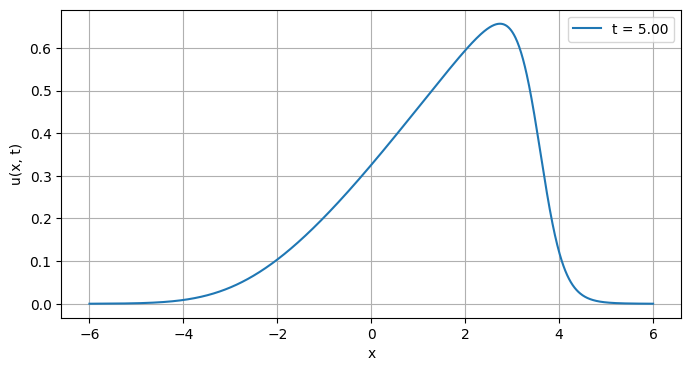

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
mu = 0.1           
CFL = 0.4      
delta_x = 0.01     
nodes = 1200       
t_end = 5.0        

x = np.linspace(-6, 6, nodes + 1)

u = np.exp(-x**2 / 2)
t = 0.0

while t < t_end:
    
    u_max = max(np.max(np.abs(u)), mu/delta_x)
    delta_t = CFL * delta_x / u_max

    f = u**2 / 2
    unext = np.copy(u)

    for j in range(1, nodes-2):
        alpha_plus = max(abs(u[j]), abs(u[j + 1]))
        f_hat_plus = 0.5 * (f[j] + f[j + 1]) - 0.5 * alpha_plus * (u[j + 1] - u[j])

        alpha_minus = max(abs(u[j - 1]), abs(u[j]))
        f_hat_minus = 0.5 * (f[j - 1] + f[j]) - 0.5 * alpha_minus * (u[j] - u[j - 1])

        unext[j] = (
            u[j]
            - (delta_t / delta_x) * (f_hat_plus - f_hat_minus)
            + (mu * delta_t / delta_x**2) * (u[j + 1] - 2 * u[j] + u[j - 1])
        )

    unext[0] = 0.0
    unext[-1] = 0.0

    u = unext.copy()
    t += delta_t


plt.figure(figsize=(8, 4))
plt.plot(x, u, label=f"t = {t:.2f}")
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.grid()
plt.legend()
plt.show()


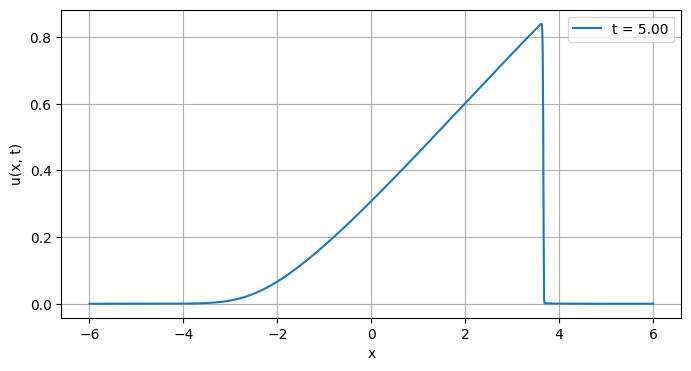

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
mu = 0         
CFL = 0.4      
delta_x = 0.01     
nodes = 1200       
t_end = 5.0        

x = np.linspace(-6, 6, nodes + 1)

u = np.exp(-x**2 / 2)
t = 0.0

while t < t_end:
    
    u_max = max(np.max(np.abs(u)), mu/delta_x)
    delta_t = CFL * delta_x / u_max

    f = u**2 / 2
    unext = np.copy(u)

    for j in range(1, nodes-2):
        alpha_plus = max(abs(u[j]), abs(u[j + 1]))
        f_hat_plus = 0.5 * (f[j] + f[j + 1]) - 0.5 * alpha_plus * (u[j + 1] - u[j])

        alpha_minus = max(abs(u[j - 1]), abs(u[j]))
        f_hat_minus = 0.5 * (f[j - 1] + f[j]) - 0.5 * alpha_minus * (u[j] - u[j - 1])

        unext[j] = (
            u[j]
            - (delta_t / delta_x) * (f_hat_plus - f_hat_minus)
            + (mu * delta_t / delta_x**2) * (u[j + 1] - 2 * u[j] + u[j - 1])
        )

    unext[0] = 0.0
    unext[-1] = 0.0

    u = unext.copy()
    t += delta_t


plt.figure(figsize=(8, 4))
plt.plot(x, u, label=f"t = {t:.2f}")
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.grid()
plt.legend()
plt.show()
